# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science**
### *Pipeline de datos: Capa Gold*
---

**Input:** `data/02_silver/dataset_analitico.csv` - 2.947 asalariados, 64 variables limpias  
**Output:** `data/03_gold/dataset_modelado.csv` - dataset listo para modelado (features + target)

---

### *Estructura del notebook*

| Sección | Contenido |
|---------|-----------|
| G.0 | Setup y carga del dataset Silver |
| G.1 | Construcción del target `estres_financiero_alto` |
| G.2 | Train / Test Split |
| G.3 | Eliminación de variables no útiles para el modelo |
| G.4 | Feature engineering |
| G.5 | Imputación semántica (no estadística) |
| G.6 | Encoding con mapa fijo |
| G.7 | Definición del ColumnTransformer y Pipeline base |
| G.8 | Verificación de integridad del Pipeline |
| G.9 | Inventario de nulos pendientes para el Pipeline |
| G.10 | Resumen del dataset Gold y exportación |
| G.11 | Decisiones de diseño — resumen |

> **Nota:** Este notebook documenta y justifica cada decisión con exploración visual.
> El código de producción ejecutable está en `gold_ecv.py`.

---


## G.0 **Configuración del entorno**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn import set_config

from utils.constants_var import PATH_SILVER_ANALITICO, COLS_AUX
from utils.mapeo_utils import COMPONENTES_ESTRES
from utils.visualizations_utils import distribucion_target

df = pd.read_csv(PATH_SILVER_ANALITICO, low_memory=False)
print(f'Dataset Silver cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')


Dataset Silver cargado: 2,947 filas × 64 columnas


## G.1 **Train / Test Split - PRIMERA OPERACIÓN**

El split se realiza **sobre el dataset Silver**, antes de cualquier transformación
que aprenda parámetros de los datos (imputación estadística, OHE, escalado).
Aplicarlo después introduciría *data leakage*: los parámetros del preprocesado
(mediana, moda, categorías del encoder) quedarían contaminados con información del test.

**Parámetros:**
- `test_size = 0.20` → 80% train / 20% test  
- `random_state = 42` → reproducibilidad  
- `stratify = y` → mantiene la proporción 84/16% en ambos conjuntos

> **Arquitectura de responsabilidades:**
> ```
> gold_ecv.py (determinista)          Notebook modelado (aprende de datos)
> ────────────────────────            ────────────────────────────────────
> Todas las transformaciones  →  PASO 1: train_test_split  ← AQUÍ
> de G.2 a G.6 son seguras         PASO 2: Pipeline.fit(X_train)
> antes del split                  PASO 3: evaluar sobre X_test
> ```


In [2]:
# Construir target preliminar para poder hacer el split estratificado
# (la construcción completa con visualizaciones está en G.2)

for col, vals in COMPONENTES_ESTRES.items():
    df[f'_comp_{col}'] = df[col].isin(vals).astype('Int64')

comp_cols = [f'_comp_{c}' for c in COMPONENTES_ESTRES]
score_comp = df[comp_cols].sum(axis=1, skipna=True)
not_nulls = df[comp_cols].notna().sum(axis=1)

df['estres_financiero_alto'] = np.where(
    score_comp >= 2, 1,
    np.where((score_comp < 2) & (not_nulls >= 4), 0, np.nan)
).astype(int)

df = df.drop(columns=comp_cols)

In [17]:
# Verificación de nulos ya que son indeterminables, no se modelan
df['estres_financiero_alto'].isna().sum()

np.int64(0)

In [3]:
# Split estratificado
X = df.drop(columns=[c for c in COLS_AUX if c in df.columns])
y = df['estres_financiero_alto'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('─' * 50)
print(f'Total observaciones:  {len(X):,}')
print(f'Train:                {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test:                 {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')
print('─' * 50)
print(f'Distribución del target:')
print(f'  Train — clase 0: {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)'
      f'  |  clase 1: {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)')
print(f'  Test  — clase 0: {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)'
      f'  |  clase 1: {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)')


──────────────────────────────────────────────────
Total observaciones:  2,947
Train:                2,357  (80.0%)
Test:                 590  (20.0%)
──────────────────────────────────────────────────
Distribución del target:
  Train — clase 0: 1,985  (84.2%)  |  clase 1: 372  (15.8%)
  Test  — clase 0: 497  (84.2%)  |  clase 1: 93  (15.8%)


In [4]:
train_set = X_train
train_set['estres_financiero_alto'] = y_train

In [5]:
test_set = X_test
test_set['estres_financiero_alto'] = y_test

> En `gold_ecv.py` se guardan los dos sets de entrenamiento y testeo en CSVs

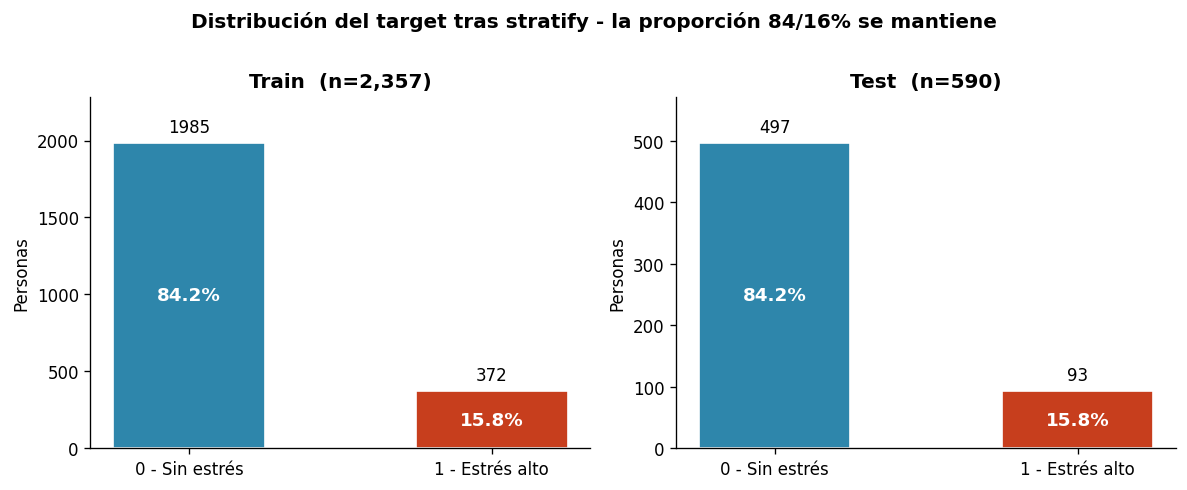

Ratio clase 1 - Train: 0.1578  |  Test: 0.1576
Diferencia absoluta:   0.0002  (debe ser < 0.005)


In [ ]:
# Visualización: distribución del target en train y test
distribucion_target(y_train, y_test)

---
## G.2 Construcción del target `estres_financiero_alto`

El target es una **variable binaria** construida a partir de 5 componentes de la ECV.
Ya fue computado en G.1 para el split estratificado. Aquí se documenta y visualiza.

**Regla:** ≥ 2 de 5 condiciones activas = estrés financiero alto.

| Componente | Variable | Condición de estrés |
|------------|----------|---------------------|
| Dificultad fin de mes | `capacidad_fin_de_mes` | `Con mucha dificultad` o `Con dificultad` |
| Sin colchón para imprevistos | `capacidad_gastos_imprevistos` | `No (no puede)` |
| Retrasos en facturas | `retrasos_facturas` | `Sí, una vez` o `Sí, dos o más veces` |
| Retrasos hipoteca/alquiler | `retrasos_hipoteca_alquiler` | `Sí, una vez` o `Sí, dos o más veces` |
| Retrasos en deudas | `retrasos_deudas_no_vivienda` | `Sí, una vez` o `Sí, dos o más veces` |

**¿Por qué ≥ 2 condiciones?** Un único indicador puede reflejar una situación puntual.
Exigir al menos dos condiciones simultáneas garantiza un perfil **persistente y multidimensional**,
coherente con la literatura sobre vulnerabilidad financiera de hogares.


In [ ]:
# ── Distribución individual de los 5 componentes (sobre el total Silver) ─
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Distribución de los 5 componentes del estrés financiero',
             fontweight='bold', y=1.01)

COLORES_COMP = {'stress': '#C73E1D', 'ok': '#2E86AB', 'nan': '#999'}

for ax, (col, vals_stress) in zip(axes, COMPONENTES.items()):
    vc = df_full[col].value_counts(dropna=False)
    colores = []
    for k in vc.index:
        if pd.isna(k):          colores.append(COLORES_COMP['nan'])
        elif k in vals_stress:  colores.append(COLORES_COMP['stress'])
        else:                   colores.append(COLORES_COMP['ok'])
    bars = ax.barh([str(k)[:25] for k in vc.index], vc.values, color=colores)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    pct_stress = df_full[col].isin(vals_stress).mean() * 100
    ax.set_title(col.replace('_', '\n'), fontsize=8, fontweight='bold')
    ax.set_xlabel(f'n  ({pct_stress:.1f}% estrés)', fontsize=8)
    ax.set_xlim(0, vc.max() * 1.2)

plt.tight_layout()
plt.savefig('gold_componentes_target.png', bbox_inches='tight')
plt.show()
print('Rojo = condición activa | Azul = sin estrés | Gris = NaN')


In [ ]:
# ── Distribución del target en el conjunto completo ──────────────────────
vc = df_split['estres_financiero_alto'].value_counts(dropna=False)
n0, n1 = vc.get(0, 0), vc.get(1, 0)
n_nan = df_full['estres_financiero_alto'].isna().sum()

print('TARGET: estres_financiero_alto')
print(f'  0 — sin estrés alto:  {n0:,}  ({n0/len(df_split)*100:.1f}%)')
print(f'  1 — estrés alto:      {n1:,}  ({n1/len(df_split)*100:.1f}%)')
print(f'  NaN (eliminados):     {n_nan:,}  ({n_nan/len(df_full)*100:.1f}%)')
print(f'  Ratio desbalanceo:    1:{n0/n1:.1f}  (clase 0 vs clase 1)')
print()
print('⚠  Desbalanceo 1:5.3 — gestionar con class_weight=\'balanced\' en el Pipeline')


---
## G.3 Eliminación de variables no útiles para el modelo

Se eliminan cuatro grupos:

1. **Constantes** — sin varianza: `region`, `situacion_actividad`, `situacion_profesional`  
2. **Identificadores** — no son features: `id_hogar`, `id_persona`  
3. **Componentes del target** — causarían *data leakage* directo  
4. **Variable duplicada** — `renta_hogar_indicadores` ≡ `renta_neta_hogar`  

> `peso_persona` **se conserva** como columna auxiliar para estadísticas ponderadas
> pero **no entra como feature** al modelo.


In [ ]:
COLS_CONSTANTES   = ['region', 'situacion_actividad', 'situacion_profesional']
COLS_IDS          = ['id_hogar', 'id_persona']
COLS_TARGET_LEAK  = list(COMPONENTES.keys())
COLS_DUPLICADAS   = ['renta_hogar_indicadores']

cols_a_eliminar = COLS_CONSTANTES + COLS_IDS + COLS_TARGET_LEAK + COLS_DUPLICADAS

# Aplicar sobre df_split (el dataset de trabajo desde aquí)
df = df_split.copy()
cols_eliminadas = [c for c in cols_a_eliminar if c in df.columns]
df = df.drop(columns=cols_eliminadas)

print(f'Columnas eliminadas: {len(cols_eliminadas)}')
for grp, cols in [
    ('Constantes',         COLS_CONSTANTES),
    ('Identificadores',    COLS_IDS),
    ('Componentes target', COLS_TARGET_LEAK),
    ('Duplicadas',         COLS_DUPLICADAS),
]:
    elim = [c for c in cols if c in cols_eliminadas]
    if elim: print(f'  {grp}: {elim}')

print(f'\nColumnas restantes: {df.shape[1]}  ({df.shape[0]:,} filas)')


---
## G.4 Feature engineering

Todas las transformaciones son **deterministas** (sin parámetros aprendidos de los datos).
Son seguras antes del split.


### G.4.1 Renta neta per cápita del hogar

La renta del hogar en bruto no es comparable entre hogares de distinto tamaño.
La escala OCDE modificada (unidades de consumo) es el estándar del INE.

$$\text{renta\_hogar\_per\_capita} = \frac{\text{renta\_neta\_hogar}}{\text{unidades\_consumo}}$$


In [ ]:
df['renta_hogar_per_capita'] = df['renta_neta_hogar'] / df['unidades_consumo']

print('renta_hogar_per_capita — estadísticas básicas:')
print(df['renta_hogar_per_capita'].describe(percentiles=[.1,.25,.5,.75,.9,.99]).round(0))


### G.4.2 Ratio de carga de vivienda sobre renta

Porcentaje de la renta salarial neta destinada a gastos de vivienda.
Un ratio > 30% es el umbral europeo de sobrecarga (Eurostat).


In [ ]:
df['ratio_carga_vivienda'] = np.where(
    df['renta_neta_salarial'] > 0,
    (df['gastos_vivienda'] * 12) / df['renta_neta_salarial'],
    np.nan
)
p99 = df['ratio_carga_vivienda'].quantile(0.99)
df['ratio_carga_vivienda'] = df['ratio_carga_vivienda'].clip(upper=p99)

fig, ax = plt.subplots(figsize=(9, 3.5))
df['ratio_carga_vivienda'].dropna().hist(bins=50, ax=ax, color='#2E86AB', alpha=0.8)
ax.axvline(0.30, color='#C73E1D', linestyle='--', lw=1.5, label='30% (umbral sobrecarga)')
ax.set_xlabel('Ratio gastos vivienda / renta salarial neta')
ax.set_ylabel('Personas')
ax.set_title('Distribución del ratio de carga de vivienda', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('gold_ratio_vivienda.png', bbox_inches='tight')
plt.show()

n_sob = (df['ratio_carga_vivienda'] > 0.30).sum()
print(f'Personas con ratio > 30% (sobrecarga): {n_sob} ({n_sob/len(df)*100:.1f}%)')


### G.4.3 Indicador de precariedad laboral

Variable binaria que combina contrato temporal Y/O jornada a tiempo parcial.


In [ ]:
es_temporal = df['tipo_contrato'].isin(['Temporal escrito', 'Temporal verbal'])
es_parcial  = df['jornada'] == 'Tiempo parcial'

df['precariedad_laboral'] = (es_temporal | es_parcial).astype('Int64')

print('Desglose del indicador de precariedad laboral:')
print(f'  Solo temporal (contrato):  {(es_temporal & ~es_parcial).sum():>5}')
print(f'  Solo parcial (jornada):    {(~es_temporal & es_parcial).sum():>5}')
print(f'  Temporal + parcial:        {(es_temporal & es_parcial).sum():>5}')
print(f'  ─────────────────────────────────')
print(f'  Total precarios:           {df["precariedad_laboral"].sum():>5}  ({df["precariedad_laboral"].mean()*100:.1f}%)')
print(f'  NaN (componente nulo):     {df["precariedad_laboral"].isna().sum():>5}')


### G.4.4 Agrupación de `nivel_estudios`

Dos categorías originales tienen n < 20 y generan inestabilidad en los modelos.
Se consolidan en 3 grupos:

| Grupo resultante | Categorías originales |
|------------------|-----------------------|
| Hasta primaria | Sin estudios + Primaria incompleta + Primaria |
| Secundaria 1ª etapa | Secundaria 1ª etapa + Secundaria 1ª etapa (título) |
| Post-secundaria | Post-secundaria no superior + Secundaria 2ª etapa (gral) |


In [ ]:
mapa_estudios = {
    'Sin estudios':                 'Hasta primaria',
    'Primaria incompleta':          'Hasta primaria',
    'Primaria':                     'Hasta primaria',
    'Secundaria 1ª etapa':          'Secundaria 1a etapa',
    'Secundaria 1ª etapa (título)': 'Secundaria 1a etapa',
    'Secundaria 2ª etapa (gral)':   'Post-secundaria',
    'Post-secundaria no superior':  'Post-secundaria',
}
df['nivel_estudios'] = df['nivel_estudios'].map(mapa_estudios)

print('Distribución tras agrupación:')
print(df['nivel_estudios'].value_counts(dropna=False).to_string())


### G.4.5 Transformación logarítmica de rentas

Las variables de renta tienen skew > 2.5. Se aplica `log1p` para estabilizar la varianza.
Se conservan las originales para árboles (no sensibles a la escala) y estadísticas descriptivas.


In [ ]:
COLS_LOG1P = [
    'renta_neta_salarial', 'renta_no_monetaria_salarial', 'renta_neta_hogar',
    'renta_hogar_per_capita', 'importe_alquiler', 'cuota_hipoteca', 'gastos_vivienda',
]

fig, axes = plt.subplots(2, len(COLS_LOG1P), figsize=(18, 6))
fig.suptitle('Efecto de log1p sobre las distribuciones de renta y vivienda', fontweight='bold')

for i, col in enumerate(COLS_LOG1P):
    if col not in df.columns: continue
    datos = df[col].dropna()
    axes[0, i].hist(datos, bins=40, color='#2E86AB', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col}\nskew={datos.skew():.2f}', fontsize=7)
    axes[0, i].set_ylabel('n' if i == 0 else '')
    datos_log = np.log1p(datos)
    axes[1, i].hist(datos_log, bins=40, color='#A23B72', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'log1p({col})\nskew={datos_log.skew():.2f}', fontsize=7)
    axes[1, i].set_ylabel('n' if i == 0 else '')

plt.tight_layout()
plt.savefig('gold_log1p_rentas.png', bbox_inches='tight')
plt.show()

for col in COLS_LOG1P:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

print(f'Variables log1p creadas: {[f"log_{c}" for c in COLS_LOG1P if c in df.columns]}')


---
## G.5 Imputación semántica (no estadística)

Solo se imputan nulos cuyo significado es conocido a priori por diseño del cuestionario.
El resto se delega al Pipeline tras el split.

- **`motivo_aumento/disminucion_ingresos`**: NaN = los ingresos no cambiaron → categoría explícita  
- **`expectativa_sin_respuesta`**: indicador binario de no-respuesta al módulo opcional  
  (el valor de `expectativa_ingresos_12m` se conserva como NaN para que el Pipeline lo impute con moda sobre train)


In [ ]:
df['motivo_aumento_ingresos']     = df['motivo_aumento_ingresos'].fillna('No aplica (sin aumento)')
df['motivo_disminucion_ingresos'] = df['motivo_disminucion_ingresos'].fillna('No aplica (sin disminucion)')

df['expectativa_sin_respuesta'] = df['expectativa_ingresos_12m'].isna().astype(int)

print(f'motivo_aumento_ingresos     — NaN restantes: {df["motivo_aumento_ingresos"].isna().sum()}')
print(f'motivo_disminucion_ingresos — NaN restantes: {df["motivo_disminucion_ingresos"].isna().sum()}')
print(f'expectativa_sin_respuesta   — personas sin respuesta: {df["expectativa_sin_respuesta"].sum()}')
print(f'expectativa_ingresos_12m    — NaN conservados para Pipeline: {df["expectativa_ingresos_12m"].isna().sum()}')


---
## G.6 Encoding con mapa fijo

Solo encodings cuyo mapa está predefinido por conocimiento del dominio.
El OHE de variables nominales se delega al Pipeline (debe ajustarse solo sobre train).

| Tipo | Criterio de seguridad |
|------|-----------------------|
| **Ordinal** | Mapa fijo con orden semántico conocido a priori |
| **Binario** | Mapa fijo 1/0, sin estadísticas |


In [ ]:
ENCODING_ORDINAL = {
    'nivel_estudios':            {'Hasta primaria': 0, 'Secundaria 1a etapa': 1, 'Post-secundaria': 2},
    'estado_salud':              {'Muy malo': 0, 'Malo': 1, 'Regular': 2, 'Bueno': 3, 'Muy bueno': 4},
    'limitacion_actividad':      {'Gravemente limitado': 0, 'Limitado (no grave)': 1, 'No limitado': 2},
    'grado_urbanizacion':        {'Zona poco poblada': 0, 'Zona media': 1, 'Zona muy poblada': 2},
    'cambio_ingresos_12m':       {'Han disminuido': 0, 'Se mantienen': 1, 'Han aumentado': 2},
    'expectativa_ingresos_12m':  {'Empeorar': 0, 'Mantenerse': 1, 'Mejorar': 2},
    'carga_prestamos_no_vivienda': {'Una carga pesada': 0, 'Una carga razonable': 1, 'Ninguna carga': 2},
    'carga_asistencia_medica':   {'Una carga pesada': 0, 'Una carga razonable': 1, 'Ninguna carga': 2, 'No ha utilizado': 3},
    'carga_asistencia_dental':   {'Una carga pesada': 0, 'Una carga razonable': 1, 'Ninguna carga': 2, 'No ha utilizado': 3},
    'carga_medicamentos':        {'Una carga pesada': 0, 'Una carga razonable': 1, 'Ninguna carga': 2, 'No ha consumido': 3},
}

for col, mapa in ENCODING_ORDINAL.items():
    if col in df.columns:
        df[col] = df[col].map(mapa)

print(f'Encoding ordinal aplicado: {len(ENCODING_ORDINAL)} variables')


In [ ]:
COLS_BINARIAS = [
    'sexo', 'jornada', 'personal_a_cargo', 'enfermedad_cronica',
    'necesito_medico_no_fue', 'puede_vacaciones', 'puede_proteina_2dias',
    'puede_calefaccion_invierno', 'hogar_riesgo_pobreza', 'hogar_carencia_material',
    'arope_2020', 'arope_2030', 'carencia_material_social_severa', 'baja_intensidad_laboral_2020',
    'puede_sustituir_muebles',
]

MAPA_BINARIO = {
    'Sí': 1.0, 'Si': 1.0, 'No': 0.0,
    'Hombre': 1.0, 'Mujer': 0.0,
    'Tiempo completo': 1.0, 'Tiempo parcial': 0.0,
    'No aplicable (≥60 años)': np.nan,
    'No aplicable (>=60 anos)': np.nan,
}

for col in COLS_BINARIAS:
    if col in df.columns:
        df[col] = df[col].map(MAPA_BINARIO)

print(f'Encoding binario aplicado: {len(COLS_BINARIAS)} variables')
print(f'NaN intencionados en baja_intensidad_laboral_2020: {df["baja_intensidad_laboral_2020"].isna().sum()}')


---
## G.7 Definición del ColumnTransformer y Pipeline base

Se clasifica cada feature según su tipo para asignar el transformador correcto:

- **`COLS_NUM`**: numéricas (continuas + ordinales + binarias ya codificadas) → `SimpleImputer(median)` + `StandardScaler`  
- **`COLS_CAT`**: nominales (`object`) → `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')`  

> El Pipeline se **ajusta solo sobre `X_train`** en el notebook de modelado.
> Aquí se define su estructura y se verifica la integridad en G.8.


In [ ]:
X_gold = df.drop(columns=['estres_financiero_alto', 'peso_persona'], errors='ignore')

COLS_NUM = X_gold.select_dtypes(include='number').columns.tolist()
COLS_CAT = X_gold.select_dtypes(include='object').columns.tolist()

print(f'COLS_NUM ({len(COLS_NUM)} variables — imputer mediana + StandardScaler):')
for c in COLS_NUM: print(f'  {c}')
print()
print(f'COLS_CAT ({len(COLS_CAT)} variables — imputer moda + OHE):')
for c in COLS_CAT: print(f'  {c}')


In [ ]:
# ── Definición del ColumnTransformer ─────────────────────────────────────
preprocesado = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), COLS_NUM),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), COLS_CAT),
    ],
    remainder='drop'
)

# ── Pipeline completo con modelo dummy para la verificación ───────────────
pipeline_base = Pipeline([
    ('preprocesado', preprocesado),
    ('modelo',       DummyClassifier(strategy='most_frequent')),
])

# Visualización del diagrama del Pipeline
set_config(display='diagram')
pipeline_base


---
## G.8 Verificación de integridad del Pipeline

Se comprueba que:
1. El Pipeline se ajusta **solo sobre `X_train`** (sin tocar `X_test`)  
2. No quedan NaN en la salida transformada  
3. Las dimensiones son consistentes  


In [ ]:
# Reconstruir X_train e y_train desde los índices guardados en G.1
# (df ya tiene el dataset Gold transformado; recuperamos los índices del split)
X_gold_train = X_gold.loc[X_train.index]
X_gold_test  = X_gold.loc[X_test.index]
y_gold_train = df.loc[X_train.index, 'estres_financiero_alto'].astype(int)

print('─' * 55)
print('VERIFICACIÓN 1: fit solo sobre X_train')
print('─' * 55)
# Fit exclusivamente sobre train
pipeline_base.fit(X_gold_train, y_gold_train)
print('  ✓ Pipeline.fit() completado sobre X_train')
print(f'    X_train: {X_gold_train.shape}')
print(f'    X_test:  {X_gold_test.shape}  ← no ha tocado ningún fit')


In [ ]:
# ── Verificación 2: sin NaN en la salida transformada ────────────────────
X_train_t = pipeline_base.named_steps['preprocesado'].transform(X_gold_train)
X_test_t  = pipeline_base.named_steps['preprocesado'].transform(X_gold_test)

nan_train = np.isnan(X_train_t).sum()
nan_test  = np.isnan(X_test_t).sum()

print('─' * 55)
print('VERIFICACIÓN 2: NaN en la salida transformada')
print('─' * 55)
print(f'  NaN en X_train transformado: {nan_train}  {"✓" if nan_train == 0 else "✗ REVISAR"}')
print(f'  NaN en X_test  transformado: {nan_test}   {"✓" if nan_test  == 0 else "✗ REVISAR"}')

print()
print('─' * 55)
print('VERIFICACIÓN 3: dimensiones')
print('─' * 55)
print(f'  X_train input:  {X_gold_train.shape}  →  output: {X_train_t.shape}')
print(f'  X_test  input:  {X_gold_test.shape}  →  output: {X_test_t.shape}')
print(f'  Columnas generadas: {X_train_t.shape[1]}  (numéricas + OHE expandidas)')

if nan_train == 0 and nan_test == 0:
    print()
    print('  ✓ Pipeline validado: sin NaN, test set intacto')


---
## G.9 Inventario de nulos pendientes para el Pipeline

Los NaN conservados serán imputados por el Pipeline ajustando parámetros **solo sobre train**.


In [ ]:
nulos = X_gold.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

tipo_nulo = {
    'baja_intensidad_laboral_2020': 'Semántico: No aplicable >=60 años → mediana (0)',
    'expectativa_ingresos_12m':     'Módulo opcional INE (9.8%) → moda en Pipeline',
    'horas_semana':                 'Informativo <2% → mediana en Pipeline',
    'limitacion_actividad':         'Informativo <2% → mediana en Pipeline',
    'meses_desempleo_5anios':       'Informativo <2% → mediana en Pipeline',
    'ratio_carga_vivienda':         'Derivado: renta_salarial=0 → mediana en Pipeline',
    'anios_experiencia':            'Informativo <2% → mediana en Pipeline',
    'tipo_contrato':                'Informativo <2% → moda en Pipeline (cat. nominal)',
}

print(f'{"Variable":<45} {"N NaN":>6}  {"%":>5}  Estrategia Pipeline')
print('-' * 100)
for col, n in nulos.items():
    est = tipo_nulo.get(col, 'Informativo <1% → mediana/moda en Pipeline')
    print(f'  {col:<43} {n:>6}  {n/len(X_gold)*100:>4.1f}%  {est}')

print(f'\nTotal variables con NaN: {len(nulos)}')
print('Todas se imputarán en el Pipeline DESPUÉS del train_test_split.')


---
## G.10 Resumen del dataset Gold y exportación


In [ ]:
X_fin = df.drop(columns=['estres_financiero_alto', 'peso_persona'], errors='ignore')
y_fin = df['estres_financiero_alto']

print(f'{'='*55}')
print(f'DATASET GOLD - RESUMEN')
print(f'{'='*55}')
print(f'  Observaciones:                      {len(df):,}')
print(f'  Features (X):')
print(f'    Numéricas/ordinales/binarias:  {len(X_fin.select_dtypes(include="number").columns)}')
print(f'    Nominales (OHE en Pipeline):   {len(X_fin.select_dtypes(include="object").columns)}')
print(f'    Total:                         {X_fin.shape[1]}')
print(f'  Nulos en X (para Pipeline):        {X_fin.isnull().sum().sum():,}')
print(f'  Target (y):')
print(f'    0 — sin estrés:              {(y_fin==0).sum():,}  ({(y_fin==0).mean()*100:.1f}%)')
print(f'    1 — estrés alto:             {(y_fin==1).sum():,}  ({(y_fin==1).mean()*100:.1f}%)')
print(f'  Ratio desbalanceo:               1:{(y_fin==0).sum()/(y_fin==1).sum():.1f}')
print(f'{'='*55}')


In [ ]:
# Exportar dataset Gold completo (X + y + peso)
PATH_GOLD.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PATH_GOLD, index=False, encoding='utf-8-sig')
print(f'Dataset Gold exportado → {PATH_GOLD}')
print(f'  {df.shape[0]:,} filas × {df.shape[1]} columnas')
print()
print('Splits ya guardados en G.1:')
print('  data/03_gold/X_train.csv')
print('  data/03_gold/X_test.csv')
print('  data/03_gold/y_train.csv')
print('  data/03_gold/y_test.csv')


---
## G.11 Decisiones de diseño — resumen

| # | Ámbito | Decisión | Justificación |
|---|--------|----------|---------------|
| 1 | **Split** | `train_test_split` es lo primero del pipeline Gold | Garantiza que ningún parámetro aprendido de los datos contamina el test set |
| 2 | Target | Umbral ≥2 de 5 condiciones para `estres_financiero_alto` | Perfil persistente y multidimensional |
| 3 | Target | NaN eliminados antes del split | Son indeterminables; no se modelan |
| 4 | Eliminación | Constantes, IDs, componentes target, duplicadas | Leakage, cero varianza o redundancia |
| 5 | Feature eng. | `renta_hogar_per_capita`, `ratio_carga_vivienda`, `precariedad_laboral` | Relaciones económicas no disponibles directamente |
| 6 | Feature eng. | `log1p` sobre rentas | Skew > 2.5; mejora modelos lineales |
| 7 | Nulos | `motivo_*_ingresos` → categoría explícita | NaN semántico por diseño del cuestionario |
| 8 | Nulos | `expectativa_sin_respuesta` como feature | Patrón de no-respuesta informativo |
| 9 | Encoding | Ordinal para variables con orden semántico | Preserva la información de orden |
| 10 | Encoding | Binario para Sí/No | Evita expansión innecesaria de OHE |
| 11 | Encoding | OHE delegado al Pipeline | Debe ajustarse solo sobre train |
| 12 | Desbalanceo | Documentado; corrección en Pipeline de modelado | Evita leakage en validación cruzada |
| 13 | Peso muestral | `peso_persona` conservado pero excluido de features | Estadísticas descriptivas y `sample_weight` |
